L'obiettivo dell'esercitazione è svolgere task di classificazione binaria sulla feature *death* e una classificazione multiclasse sulla feature *dzgroup* e una regressione sulla feature *aps* 

# Caricamento dataset


In [1]:
import pandas as pd

df = pd.read_csv("dataset_esercitazione.csv")
print(df.head())
print(df.shape)

        age     sex            dzgroup             dzclass  num.co   edu  \
0  62.84998    male        Lung Cancer              Cancer       0  11.0   
1  60.33899  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
2  52.74698  female          Cirrhosis  COPD/CHF/Cirrhosis       2  12.0   
3  42.38498  female        Lung Cancer              Cancer       2  11.0   
4  79.88495  female  ARF/MOSF w/Sepsis            ARF/MOSF       1   NaN   

       income  scoma  charges  totcst  ...      crea    sod        ph  \
0    $11-$25k    0.0   9715.0     NaN  ...  1.199951  141.0  7.459961   
1    $11-$25k   44.0  34496.0     NaN  ...  5.500000  132.0  7.250000   
2  under $11k    0.0  41094.0     NaN  ...  2.000000  134.0  7.459961   
3  under $11k    0.0   3075.0     NaN  ...  0.799927  139.0       NaN   
4         NaN   26.0  50127.0     NaN  ...  0.799927  143.0  7.509766   

   glucose  bun  urine  adlp  adls  adlsc  death  
0      NaN  NaN    NaN   7.0   7.0    7.0      0  
1 

# Analisi valori NaN e imputazione dati mancanti

In [2]:
# Sceglieremo una soglia percentuale e andremo ad eliminare le colonne eccessivamente sparse

missing_pct = df.isna().mean(axis=0) * 100
cols_to_drop = missing_pct[missing_pct > 30].index.to_list()

print(missing_pct.sort_values(ascending=False)) # osserviamo i valori mancanti per ciascun colonna

#eliminiamo le feature con percentuale di valori mancanti maggiore del 30%.
df = df.drop(columns=cols_to_drop)
print(f"Colonne eliminate: {cols_to_drop}")

adlp        61.954970
urine       53.399231
glucose     49.423394
bun         47.797913
totmcst     38.165843
alb         37.034596
income      32.751236
adls        31.488193
bili        28.566722
pafi        25.535420
ph          25.085118
prg2m       18.110928
edu         17.946183
prg6m       17.935200
totcst       9.752883
wblc         2.328391
charges      1.889072
avtisst      0.900604
crea         0.735859
race         0.461285
dnr          0.329489
dnrday       0.329489
sps          0.010983
surv2m       0.010983
scoma        0.010983
resp         0.010983
temp         0.010983
sod          0.010983
hrt          0.010983
meanbp       0.010983
aps          0.010983
surv6m       0.010983
age          0.000000
sex          0.000000
dzgroup      0.000000
num.co       0.000000
dzclass      0.000000
hday         0.000000
diabetes     0.000000
ca           0.000000
dementia     0.000000
adlsc        0.000000
death        0.000000
dtype: float64
Colonne eliminate: ['income', 'totmcst'

In [3]:
# Calcoliamo la percentuale di valori mancanti anche per le righe
missing_rows_pct = df.isna().mean(axis=1) * 100
print(missing_rows_pct.describe())

count    9105.000000
mean        4.286185
std         4.170371
min         0.000000
25%         0.000000
50%         2.857143
75%         5.714286
max        42.857143
dtype: float64


In [4]:
rows_to_drop = missing_rows_pct[missing_rows_pct > 40].index
df = df.drop(index = rows_to_drop)

print(f"Righe eliminate: {len(rows_to_drop)}")


Righe eliminate: 1


In [5]:
print(f"Nuova dimensione: {df.shape}")

Nuova dimensione: (9104, 35)


# Split e preprocessing
Dovendo effettuare tre task differenti andremo ad estrarre tre etichette e creeremo tre DataFrame differenti per ciascun task:

In [11]:
y_death = df["death"]
y_dzgroup = df["dzgroup"]
y_aps = df["aps"]

X_death = df.drop(columns=["death"])
X_dzgroup = df.drop(columns=["dzgroup"])
X_aps = df.drop(columns=["aps"])



from sklearn.model_selection import train_test_split

X_train_death, X_test_death, y_train_death, y_test_death = train_test_split(X_death, y_death, stratify=y_death, random_state=42, test_size=0.15)
X_train_dzgroup, X_test_dzgroup, y_train_dzgroup, y_test_dzgroup = train_test_split(X_dzgroup, y_dzgroup, stratify=y_dzgroup, random_state=42, test_size=0.15)
X_train_aps, X_test_aps, y_train_aps, y_test_aps = train_test_split(X_aps, y_aps, random_state=42, test_size=0.15)

# PREPROCESSING DEATH
cat_cols_death = X_train_death.select_dtypes(include=["object", "bool", "category"]).columns
num_cols_death = X_train_death.columns.drop(cat_cols_death)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler

# Creiamo la pipeline di preprocessing

# Pipeline per le colonne categoriche
cat_pipe_death = Pipeline(steps=[
    ("imputer", SimpleImputer(fill_value="Unknown", strategy="constant")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Pipeline per le colonne numeriche
num_pipe_death = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_death = ColumnTransformer(transformers=[
    ('cat', cat_pipe_death, cat_cols_death),
    ('num', num_pipe_death, num_cols_death)
])

preprocessor_death.set_output(transform="pandas")

X_train_death_processed = preprocessor_death.fit_transform(X_train_death)
X_test_death_processed = preprocessor_death.transform(X_test_death)


## Dopo aver effettuato il preprocessing per il primo task procediamo a svolgerlo per il secondo task 

In [7]:
# preprocessing per dzgroup per task di classificazione multi-classe
cat_cols_dzgroup = X_train_dzgroup.select_dtypes(include=["object", "bool", "category"]).columns
num_cols_dzgroup = X_train_dzgroup.columns.drop(cat_cols_dzgroup)

# Creiamo la pipeline di preprocessing

# Pipeline per le colonne categoriche
cat_pipe_dzgroup = Pipeline(steps=[
    ("imputer", SimpleImputer(fill_value="Unknown", strategy="constant")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Pipeline per le colonne numeriche
num_pipe_dzgroup = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_dzgroup = ColumnTransformer(transformers=[
    ('cat', cat_pipe_dzgroup, cat_cols_dzgroup),
    ('num', num_pipe_dzgroup, num_cols_dzgroup)
])

preprocessor_dzgroup.set_output(transform="pandas")

X_train_dzgroup_processed = preprocessor_dzgroup.fit_transform(X_train_dzgroup)
X_test_processed = preprocessor_dzgroup.transform(X_test_dzgroup)

## Infine svolgiamo il preprocessing anche per aps


In [8]:
# preprocessing per aps per task di regressione
cat_cols_aps = X_train_aps.select_dtypes(include=["object", "bool", "category"]).columns
num_cols_aps = X_train_aps.columns.drop(cat_cols_aps)

# Creiamo la pipeline di preprocessing

# Pipeline per le colonne categoriche
cat_pipe_aps = Pipeline(steps=[
    ("imputer", SimpleImputer(fill_value="Unknown", strategy="constant")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

# Pipeline per le colonne numeriche
num_pipe_aps = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor_aps = ColumnTransformer(transformers=[
    ('cat', cat_pipe_aps, cat_cols_aps),
    ('num', num_pipe_aps, num_cols_aps)
])

preprocessor_aps.set_output(transform="pandas")

X_train_aps_processed = preprocessor_aps.fit_transform(X_train_aps)
X_test_aps_processed = preprocessor_aps.transform(X_test_aps)

# Analisi Matrice di correlazione per task di classificazione (death)

['num__surv6m', 'num__prg6m']
Feature correlate con death: []
Feature multicollineari: ['num__surv6m', 'num__prg6m']


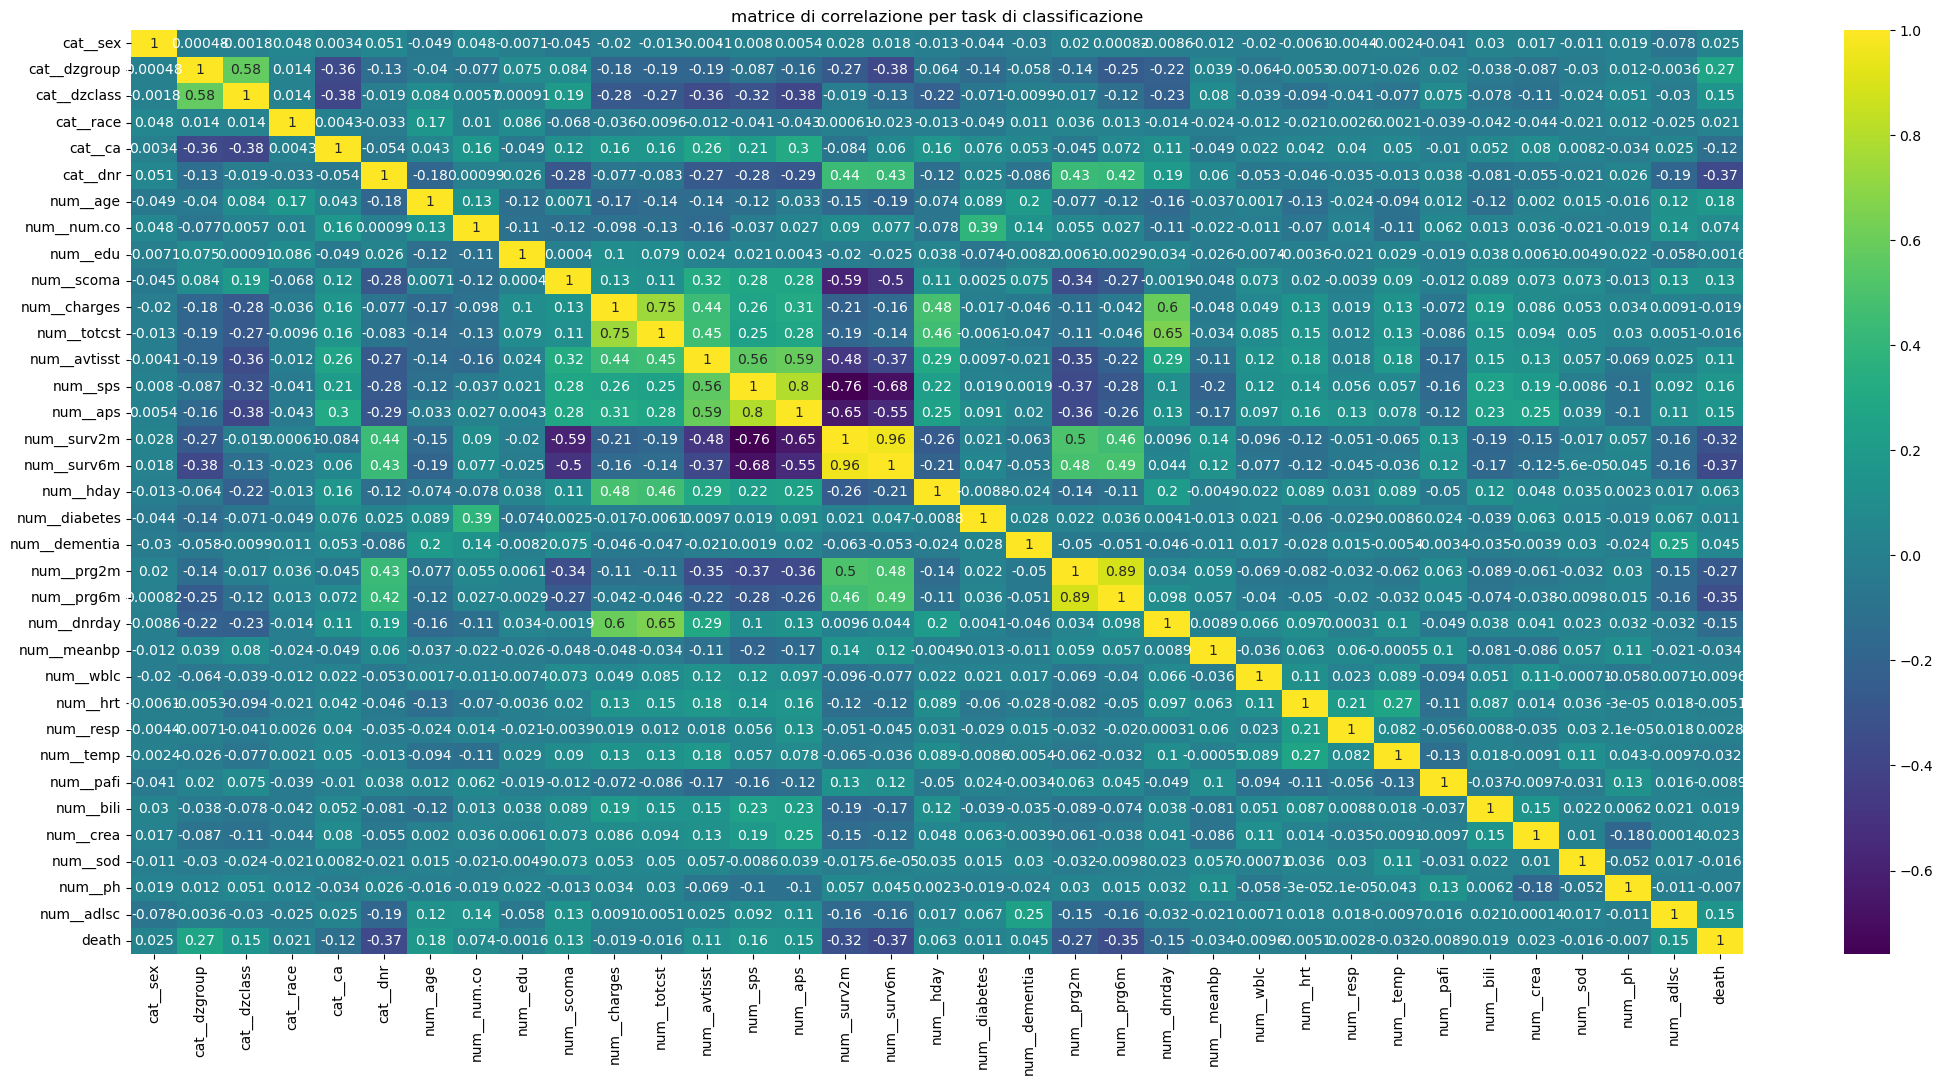

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Aggiungiamo temporaneamente la colonna death al dataframe processato per analizzare la correlazione

corr_death = X_train_death_processed.copy()
corr_death["death"] = y_train_death.to_numpy()

corr_death_matrix = corr_death.corr()

# analisi correlazione con feature target
target_corr_death = (corr_death_matrix["death"].drop("death").abs().sort_values(ascending=False))
# Eliminiamo soltato le feature con un'alta correlazione
target_feature_to_drop = target_corr_death[ target_corr_death > 0.90].index.tolist()

# Analisi feature multicollineari

# Analizziamo la matrice senza il target
feature_corr_death = corr_death_matrix.drop(index="death", columns="death").abs()


tri_upper = feature_corr_death.where(np.triu(np.ones(feature_corr_death.shape), k=1).astype(bool))
feature_multicollineari = feature_corr_death.columns[ (tri_upper.abs()> 0.80).sum() > 0 ].tolist()
print(feature_multicollineari)

# Un'unica eliminazione dal train e dal test
columns_to_drop = list(set(target_feature_to_drop + feature_multicollineari))

X_train_death_processed = X_train_death_processed.drop(columns=columns_to_drop)
X_test_death_processed = X_test_death_processed.drop(columns=columns_to_drop)

print(f"Feature correlate con death: {target_feature_to_drop}")
print(f"Feature multicollineari: {feature_multicollineari}")

plt.figure(figsize=(26,12))
plt.title("matrice di correlazione per task di classificazione")
sns.heatmap(corr_death_matrix, cmap="viridis", annot=True)
plt.show()





## Analisi correlazione per il secondo task
Essendo un task di classificazione multiclasse e' meglio creare una variabile binaria per ogni classe, secondo il criterio *one-vs-rest*


In [ ]:
# Aggiungiamo le classi di dzgroup in forma one_vs_rest

dzgroup_dummies = pd.get_dummies(
    y_train_dzgroup,
    prefix="dzgroup",
    dtype=int
)
# Aggiungiamo le classi al
corr_dzgroup = X_train_dzgroup_processed.copy()

corr_dzgroup[dzgroup_dummies.columns] = dzgroup_dummies